In [ ]:
import kagglehub

# Downloads the dataset to a local cache folder
path = kagglehub.dataset_download("fatemehmehrparvar/lung-disease")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lung-disease' dataset.
Path to dataset files: /kaggle/input/lung-disease


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import seaborn as sns

# ─── 1. PATHS ─────────────────────────────────────────────────────────
BASE_PATH          = "/kaggle/input/lung-disease/Lung X-Ray Image/Lung X-Ray Image"
lung_opacity_path  = os.path.join(BASE_PATH, "Lung_Opacity")
normal_path        = os.path.join(BASE_PATH, "Normal")
viral_pneumonia_path = os.path.join(BASE_PATH, "Viral Pneumonia")

print("Lung Opacity images :", len(os.listdir(lung_opacity_path)))
print("Normal images       :", len(os.listdir(normal_path)))
print("Viral Pneumonia imgs:", len(os.listdir(viral_pneumonia_path)))


Lung Opacity images : 1125
Normal images       : 1250
Viral Pneumonia imgs: 1100


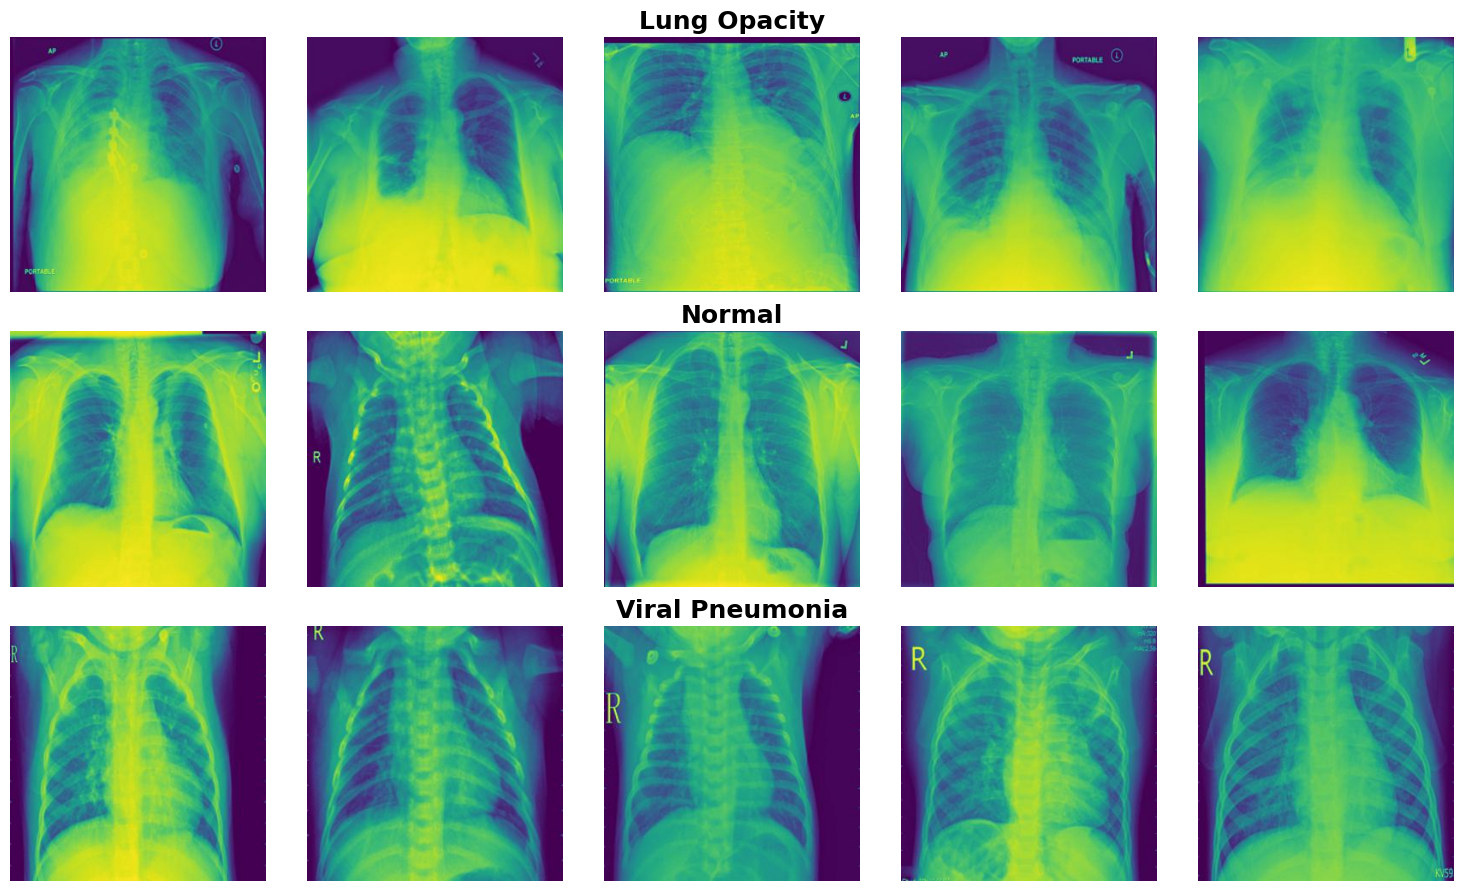

In [ ]:
# ---------------- Function to load sample images ----------------
def load_samples(path, num_samples=5):
    valid_ext = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')
    files = [f for f in os.listdir(path) if f.lower().endswith(valid_ext)][:num_samples]
    images = [Image.open(os.path.join(path, f)).convert('RGB') for f in files]
    return images

# Load 5 sample images from each class
lung_opacity_imgs   = load_samples(lung_opacity_path)
normal_imgs         = load_samples(normal_path)
viral_pneumonia_imgs = load_samples(viral_pneumonia_path)

# ---------------- Plotting ----------------
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

# Row 1: Lung Opacity
for i, img in enumerate(lung_opacity_imgs):
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].axis('off')
    if i == 2:
        axes[0, i].set_title("Lung Opacity", fontsize=18, fontweight='bold')

# Row 2: Normal
for i, img in enumerate(normal_imgs):
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].axis('off')
    if i == 2:
        axes[1, i].set_title("Normal", fontsize=18, fontweight='bold')

# Row 3: Viral Pneumonia
for i, img in enumerate(viral_pneumonia_imgs):
    axes[2, i].imshow(img, cmap='gray')
    axes[2, i].axis('off')
    if i == 2:
        axes[2, i].set_title("Viral Pneumonia", fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

Lung Opacity: 1125 images
Normal: 1250 images
Viral Pneumonia: 1100 images


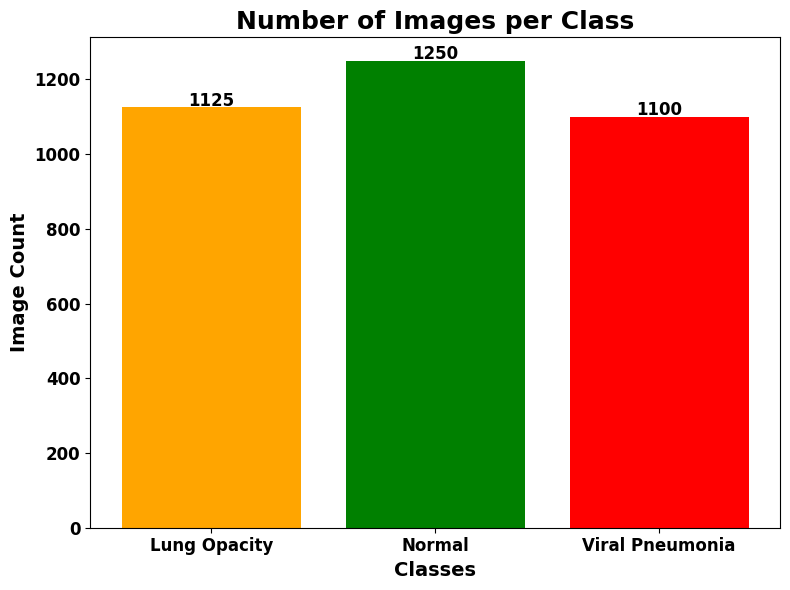

In [ ]:
import matplotlib.pyplot as plt
import os

# ---------------- Count images using existing paths ----------------
valid_ext = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')

def count_images(path):
    return len([f for f in os.listdir(path) if f.lower().endswith(valid_ext)])

class_counts = {
    "Lung Opacity"   : count_images(lung_opacity_path),
    "Normal"         : count_images(normal_path),
    "Viral Pneumonia": count_images(viral_pneumonia_path)
}

# Print counts
for cls, count in class_counts.items():
    print(f"{cls}: {count} images")

# ---------------- Plot bar chart ----------------
plt.figure(figsize=(8, 6))
bars = plt.bar(class_counts.keys(), class_counts.values(), color=['orange', 'green', 'red'])

plt.title("Number of Images per Class", fontsize=18, fontweight='bold')
plt.ylabel("Image Count", fontsize=14, fontweight='bold')
plt.xlabel("Classes", fontsize=14, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, str(yval),  # ← str() fix too
             ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
import os
from PIL import Image
import numpy as np

# ---------------- Parameters ----------------
target_size      = (224, 224)
output_base_path = "/kaggle/working/preprocessed_images"
valid_ext        = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')

# Make class folders in output directory
os.makedirs(output_base_path, exist_ok=True)

class_paths = {
    "Lung_Opacity"   : lung_opacity_path,
    "Normal"         : normal_path,
    "Viral_Pneumonia": viral_pneumonia_path
}

for cls in class_paths.keys():
    os.makedirs(os.path.join(output_base_path, cls), exist_ok=True)

# ---------------- Preprocessing Function ----------------
def preprocess_and_save(input_path, output_path, target_size):
    files = [f for f in os.listdir(input_path) if f.lower().endswith(valid_ext)]
    skipped = 0
    for f in files:
        try:
            img = Image.open(os.path.join(input_path, f)).convert('RGB')  # ← RGB, not grayscale
            img = img.resize(target_size)

            # Normalize to [0,1] then back to uint8 for saving
            img_array = (np.array(img) / 255.0 * 255).astype(np.uint8)

            # Always save as .jpg to avoid format mismatch issues
            save_name = os.path.splitext(f)[0] + ".jpg"
            save_path = os.path.join(output_path, save_name)
            Image.fromarray(img_array).save(save_path)

        except Exception as e:
            print(f"Skipped {f}: {e}")
            skipped += 1

    print(f"  ✓ {len(files) - skipped}/{len(files)} images saved  ({skipped} skipped)")

# ---------------- Process all classes ----------------
for cls, path in class_paths.items():
    print(f"Processing: {cls}")
    preprocess_and_save(path, os.path.join(output_base_path, cls), target_size)

print("\nAll images preprocessed and saved successfully!")

Processing: Lung_Opacity
  ✓ 1125/1125 images saved  (0 skipped)
Processing: Normal
  ✓ 1250/1250 images saved  (0 skipped)
Processing: Viral_Pneumonia
  ✓ 1100/1100 images saved  (0 skipped)

All images preprocessed and saved successfully!


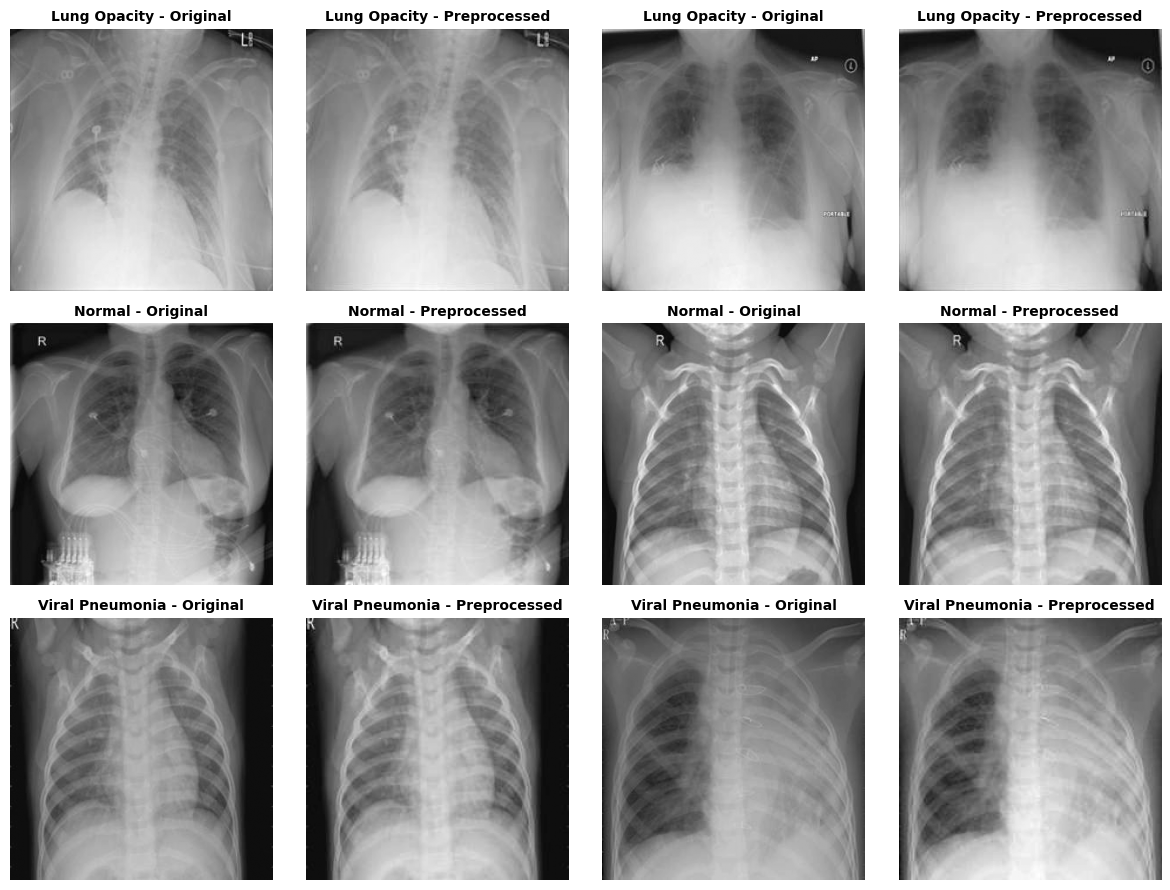

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import pandas as pd
import os

# ---------------- Paths ----------------
valid_ext = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')

input_dirs = {
    "Lung Opacity"   : lung_opacity_path,
    "Normal"         : normal_path,
    "Viral Pneumonia": viral_pneumonia_path
}

output_dirs = {
    "Lung Opacity"   : "/kaggle/working/preprocessed_images/Lung_Opacity",
    "Normal"         : "/kaggle/working/preprocessed_images/Normal",
    "Viral Pneumonia": "/kaggle/working/preprocessed_images/Viral_Pneumonia"
}

# ---------------- Function to create a DataFrame of filenames ----------------
def create_df(image_dir, label):
    files = [f for f in os.listdir(image_dir) if f.lower().endswith(valid_ext)]
    df = pd.DataFrame({
        'filename': files,
        'labels'  : [label] * len(files)
    })
    return df

# Create a single DataFrame for all classes
df_lung_opacity = create_df(input_dirs["Lung Opacity"],   "Lung Opacity")
df_normal       = create_df(input_dirs["Normal"],          "Normal")
df_viral        = create_df(input_dirs["Viral Pneumonia"], "Viral Pneumonia")
df_csv = pd.concat([df_lung_opacity, df_normal, df_viral], ignore_index=True)

# ---------------- Pick 2 samples per class ----------------
sample_lo = df_csv[df_csv['labels'] == 'Lung Opacity'].sample(2, random_state=42)
sample_n  = df_csv[df_csv['labels'] == 'Normal'].sample(2, random_state=42)
sample_vp = df_csv[df_csv['labels'] == 'Viral Pneumonia'].sample(2, random_state=42)

# ---------------- Create figure ----------------
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

# ---------------- Function to show comparison ----------------
def show_comparison(row, row_idx, col_idx, title_class):
    orig_filename = row['filename']
    pre_filename  = os.path.splitext(orig_filename)[0] + ".jpg"

    orig_path = os.path.join(input_dirs[title_class],  orig_filename)
    pre_path  = os.path.join(output_dirs[title_class], pre_filename)

    # Original
    orig = Image.open(orig_path).convert('L')           # ← grayscale for display
    axes[row_idx, col_idx].imshow(orig, cmap='gray')
    axes[row_idx, col_idx].axis('off')
    axes[row_idx, col_idx].set_title(f"{title_class} - Original", fontsize=10, fontweight="bold")

    # Preprocessed
    pre = Image.open(pre_path).convert('L')             # ← grayscale for display
    axes[row_idx, col_idx+1].imshow(pre, cmap='gray')
    axes[row_idx, col_idx+1].axis('off')
    axes[row_idx, col_idx+1].set_title(f"{title_class} - Preprocessed", fontsize=10, fontweight="bold")

# ---------------- Plot rows ----------------
for i, (_, row) in enumerate(sample_lo.iterrows()):
    show_comparison(row, 0, i*2, "Lung Opacity")

for i, (_, row) in enumerate(sample_n.iterrows()):
    show_comparison(row, 1, i*2, "Normal")

for i, (_, row) in enumerate(sample_vp.iterrows()):
    show_comparison(row, 2, i*2, "Viral Pneumonia")

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
from sklearn.model_selection import train_test_split

# ---------------- Parameters ----------------
img_size    = (224, 224)
batch_size  = 32
num_epochs  = 50          # high ceiling, early stopping will cut it
num_classes = 3
patience    = 5           # stop if val_loss doesn't improve for 5 epochs
device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
valid_ext   = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')

# ---------------- Dataset ----------------
class LungXRayDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('L')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# ---------------- Load paths ----------------
preprocessed_dirs = {
    "Lung_Opacity"   : "/kaggle/working/preprocessed_images/Lung_Opacity",
    "Normal"         : "/kaggle/working/preprocessed_images/Normal",
    "Viral_Pneumonia": "/kaggle/working/preprocessed_images/Viral_Pneumonia"
}

def get_image_paths_and_labels(preprocessed_dirs):
    image_paths, labels = [], []
    for i, (cls, path) in enumerate(preprocessed_dirs.items()):
        for f in os.listdir(path):
            if f.lower().endswith(valid_ext):
                image_paths.append(os.path.join(path, f))
                labels.append(i)
    return image_paths, labels

image_paths, labels = get_image_paths_and_labels(preprocessed_dirs)
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42
)

# ---------------- Transforms (with augmentation) ----------------
train_transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),   # ← augmentation
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

test_transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_loader = DataLoader(LungXRayDataset(train_paths, train_labels, train_transform), batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(LungXRayDataset(test_paths,  test_labels,  test_transform),  batch_size=batch_size, shuffle=False)

# ---------------- CNN Model ----------------
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model     = SimpleCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ---------------- Training with Early Stopping ----------------
cnn_train_losses, cnn_val_losses = [], []
cnn_train_accs,   cnn_val_accs   = [], []

best_val_loss     = float('inf')
patience_counter  = 0
best_epoch        = 0

for epoch in range(num_epochs):
    # Train
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    for images, lbls in train_loader:
        images, lbls = images.to(device), lbls.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item()
        _, pred        = torch.max(outputs, 1)
        total_train   += lbls.size(0)
        correct_train += (pred == lbls).sum().item()

    train_loss_avg = train_loss / len(train_loader)
    train_acc      = 100 * correct_train / total_train

    # Validate
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, lbls in test_loader:
            images, lbls = images.to(device), lbls.to(device)
            outputs       = model(images)
            loss          = criterion(outputs, lbls)
            val_loss     += loss.item()
            _, pred        = torch.max(outputs, 1)
            total_val    += lbls.size(0)
            correct_val  += (pred == lbls).sum().item()

    val_loss_avg = val_loss / len(test_loader)
    val_acc      = 100 * correct_val / total_val

    cnn_train_losses.append(train_loss_avg); cnn_val_losses.append(val_loss_avg)
    cnn_train_accs.append(train_acc);        cnn_val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss_avg:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss_avg:.4f} | Val Acc: {val_acc:.2f}%")

    # Early Stopping
    if val_loss_avg < best_val_loss:
        best_val_loss = val_loss_avg
        best_epoch    = epoch + 1
        torch.save(model.state_dict(), "/kaggle/working/best_cnn.pth")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n⏹ Early stopping at epoch {epoch+1} | Best epoch: {best_epoch}")
            break

print(f"\n✅ CNN Best Val Accuracy: {max(cnn_val_accs):.2f}%")

Epoch [1/50] Train Loss: 0.7083 | Train Acc: 69.57% | Val Loss: 0.5153 | Val Acc: 81.01%
Epoch [2/50] Train Loss: 0.5326 | Train Acc: 78.17% | Val Loss: 0.4702 | Val Acc: 81.15%
Epoch [3/50] Train Loss: 0.4900 | Train Acc: 79.82% | Val Loss: 0.4432 | Val Acc: 84.32%
Epoch [4/50] Train Loss: 0.4716 | Train Acc: 79.96% | Val Loss: 0.4464 | Val Acc: 82.59%
Epoch [5/50] Train Loss: 0.4274 | Train Acc: 81.44% | Val Loss: 0.4122 | Val Acc: 83.60%
Epoch [6/50] Train Loss: 0.4120 | Train Acc: 82.41% | Val Loss: 0.3635 | Val Acc: 86.33%
Epoch [7/50] Train Loss: 0.3912 | Train Acc: 83.74% | Val Loss: 0.3787 | Val Acc: 85.76%
Epoch [8/50] Train Loss: 0.3651 | Train Acc: 85.58% | Val Loss: 0.3503 | Val Acc: 86.19%
Epoch [9/50] Train Loss: 0.3444 | Train Acc: 85.54% | Val Loss: 0.3796 | Val Acc: 84.89%
Epoch [10/50] Train Loss: 0.3427 | Train Acc: 86.22% | Val Loss: 0.3310 | Val Acc: 86.62%
Epoch [11/50] Train Loss: 0.3263 | Train Acc: 87.12% | Val Loss: 0.3398 | Val Acc: 87.48%
Epoch [12/50] Train

In [ ]:
from torchvision import models

# ---------------- Transforms (RGB for ResNet) ----------------
resnet_train_transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.Grayscale(num_output_channels=3),   # ← ResNet needs 3 channels
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],    # ← ImageNet mean
                         [0.229, 0.224, 0.225])     # ← ImageNet std
])

resnet_test_transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Reuse same paths
class LungXRayDatasetRGB(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('L')  # load grayscale
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

resnet_train_loader = DataLoader(LungXRayDatasetRGB(train_paths, train_labels, resnet_train_transform), batch_size=batch_size, shuffle=True)
resnet_test_loader  = DataLoader(LungXRayDatasetRGB(test_paths,  test_labels,  resnet_test_transform),  batch_size=batch_size, shuffle=False)

# ---------------- ResNet18 Model ----------------
resnet_model = models.resnet18(weights='IMAGENET1K_V1')

# Freeze all layers except final
for param in resnet_model.parameters():
    param.requires_grad = False

# Replace final layer for 3 classes
resnet_model.fc = nn.Sequential(
    nn.Linear(resnet_model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes)
)

resnet_model  = resnet_model.to(device)
resnet_optim  = optim.Adam(resnet_model.fc.parameters(), lr=0.001)

# ---------------- Training ----------------
resnet_train_losses, resnet_val_losses = [], []
resnet_train_accs,   resnet_val_accs   = [], []

best_resnet_val_loss = float('inf')
resnet_patience      = 0
best_resnet_epoch    = 0

for epoch in range(num_epochs):
    resnet_model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    for images, lbls in resnet_train_loader:
        images, lbls = images.to(device), lbls.to(device)
        resnet_optim.zero_grad()
        outputs = resnet_model(images)
        loss    = criterion(outputs, lbls)
        loss.backward()
        resnet_optim.step()
        train_loss    += loss.item()
        _, pred        = torch.max(outputs, 1)
        total_train   += lbls.size(0)
        correct_train += (pred == lbls).sum().item()

    train_loss_avg = train_loss / len(resnet_train_loader)
    train_acc      = 100 * correct_train / total_train

    resnet_model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, lbls in resnet_test_loader:
            images, lbls = images.to(device), lbls.to(device)
            outputs       = resnet_model(images)
            loss          = criterion(outputs, lbls)
            val_loss     += loss.item()
            _, pred        = torch.max(outputs, 1)
            total_val    += lbls.size(0)
            correct_val  += (pred == lbls).sum().item()

    val_loss_avg = val_loss / len(resnet_test_loader)
    val_acc      = 100 * correct_val / total_val

    resnet_train_losses.append(train_loss_avg); resnet_val_losses.append(val_loss_avg)
    resnet_train_accs.append(train_acc);        resnet_val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss_avg:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss_avg:.4f} | Val Acc: {val_acc:.2f}%")

    if val_loss_avg < best_resnet_val_loss:
        best_resnet_val_loss = val_loss_avg
        best_resnet_epoch    = epoch + 1
        torch.save(resnet_model.state_dict(), "/kaggle/working/best_resnet.pth")
        resnet_patience = 0
    else:
        resnet_patience += 1
        if resnet_patience >= patience:
            print(f"\n⏹ Early stopping at epoch {epoch+1} | Best epoch: {best_resnet_epoch}")
            break

print(f"\n✅ ResNet18 Best Val Accuracy: {max(resnet_val_accs):.2f}%")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 146MB/s]


Epoch [1/50] Train Loss: 0.6855 | Train Acc: 71.22% | Val Loss: 0.4548 | Val Acc: 80.58%
Epoch [2/50] Train Loss: 0.4965 | Train Acc: 79.96% | Val Loss: 0.3585 | Val Acc: 86.04%
Epoch [3/50] Train Loss: 0.4274 | Train Acc: 83.06% | Val Loss: 0.4517 | Val Acc: 80.86%
Epoch [4/50] Train Loss: 0.4173 | Train Acc: 82.91% | Val Loss: 0.3238 | Val Acc: 85.61%
Epoch [5/50] Train Loss: 0.3972 | Train Acc: 84.17% | Val Loss: 0.3576 | Val Acc: 86.19%
Epoch [6/50] Train Loss: 0.3970 | Train Acc: 83.02% | Val Loss: 0.3039 | Val Acc: 87.34%
Epoch [7/50] Train Loss: 0.3885 | Train Acc: 84.14% | Val Loss: 0.3754 | Val Acc: 86.04%
Epoch [8/50] Train Loss: 0.4005 | Train Acc: 83.96% | Val Loss: 0.3090 | Val Acc: 87.77%
Epoch [9/50] Train Loss: 0.3465 | Train Acc: 85.86% | Val Loss: 0.3109 | Val Acc: 85.61%
Epoch [10/50] Train Loss: 0.3393 | Train Acc: 86.26% | Val Loss: 0.3019 | Val Acc: 89.06%
Epoch [11/50] Train Loss: 0.3481 | Train Acc: 86.29% | Val Loss: 0.3092 | Val Acc: 86.04%
Epoch [12/50] Train

Train: 2780 | Test: 695
PHASE 1 — Frozen Backbone (FC only)
[Phase1] Epoch [1/20] Train Loss: 0.6494 | Train Acc: 72.77% | Val Loss: 0.4082 | Val Acc: 83.60%
[Phase1] Epoch [2/20] Train Loss: 0.4865 | Train Acc: 80.50% | Val Loss: 0.3485 | Val Acc: 85.76%
[Phase1] Epoch [3/20] Train Loss: 0.4240 | Train Acc: 82.70% | Val Loss: 0.3796 | Val Acc: 83.74%
[Phase1] Epoch [4/20] Train Loss: 0.4091 | Train Acc: 83.56% | Val Loss: 0.3063 | Val Acc: 88.06%
[Phase1] Epoch [5/20] Train Loss: 0.4023 | Train Acc: 84.68% | Val Loss: 0.3420 | Val Acc: 86.91%
[Phase1] Epoch [6/20] Train Loss: 0.3784 | Train Acc: 84.96% | Val Loss: 0.3263 | Val Acc: 85.61%
[Phase1] Epoch [7/20] Train Loss: 0.3849 | Train Acc: 84.68% | Val Loss: 0.3074 | Val Acc: 88.06%
[Phase1] Epoch [8/20] Train Loss: 0.3633 | Train Acc: 85.50% | Val Loss: 0.3529 | Val Acc: 85.76%
[Phase1] Epoch [9/20] Train Loss: 0.3644 | Train Acc: 84.82% | Val Loss: 0.3471 | Val Acc: 87.19%

⏹ Early stopping at epoch 9 | Best epoch: 4

✅ [Phase1] B

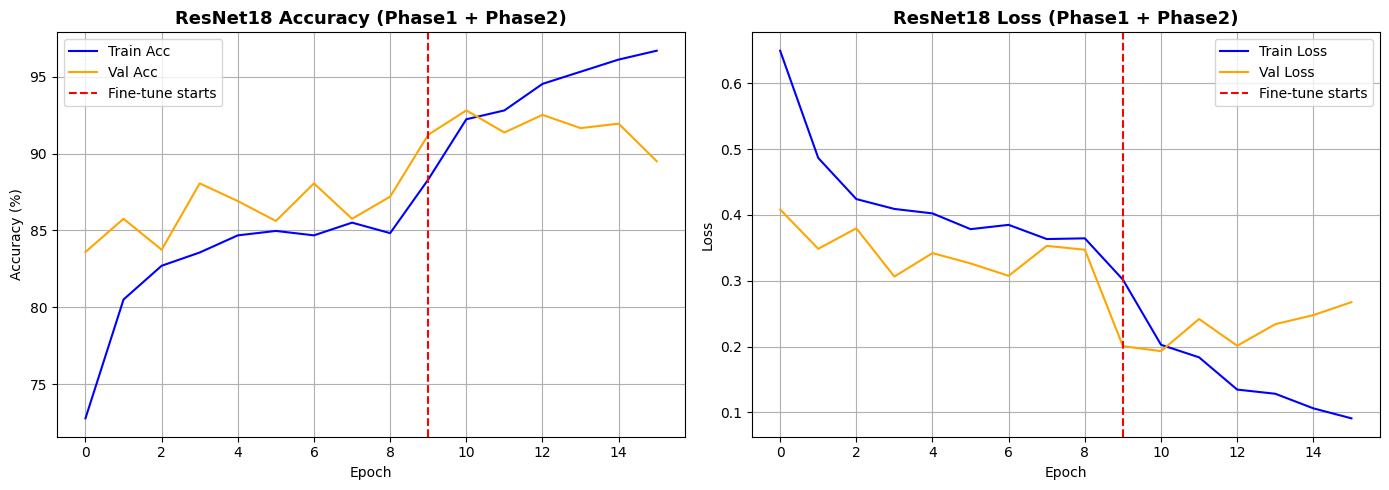


📊 Final Summary
Phase          Best Val Acc
----------------------------
Phase 1              88.06%
Phase 2              92.81%
Overall              92.81%


In [ ]:
from torchvision import models
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
from sklearn.model_selection import train_test_split

# ---------------- Parameters ----------------
img_size    = (224, 224)
batch_size  = 32
num_epochs  = 50
num_classes = 3
patience    = 5
device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
valid_ext   = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')

# ---------------- Dataset ----------------
class LungXRayDatasetRGB(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('L')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# ---------------- Load Paths ----------------
preprocessed_dirs = {
    "Lung_Opacity"   : "/kaggle/working/preprocessed_images/Lung_Opacity",
    "Normal"         : "/kaggle/working/preprocessed_images/Normal",
    "Viral_Pneumonia": "/kaggle/working/preprocessed_images/Viral_Pneumonia"
}

def get_image_paths_and_labels(preprocessed_dirs):
    image_paths, labels = [], []
    for i, (cls, path) in enumerate(preprocessed_dirs.items()):
        for f in os.listdir(path):
            if f.lower().endswith(valid_ext):
                image_paths.append(os.path.join(path, f))
                labels.append(i)
    return image_paths, labels

image_paths, labels = get_image_paths_and_labels(preprocessed_dirs)
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42
)
print(f"Train: {len(train_paths)} | Test: {len(test_paths)}")

# ---------------- Transforms ----------------
resnet_train_transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

resnet_test_transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

resnet_train_loader = DataLoader(
    LungXRayDatasetRGB(train_paths, train_labels, resnet_train_transform),
    batch_size=batch_size, shuffle=True
)
resnet_test_loader = DataLoader(
    LungXRayDatasetRGB(test_paths, test_labels, resnet_test_transform),
    batch_size=batch_size, shuffle=False
)

# ---------------- ResNet18 Model (PHASE 1 — frozen backbone) ----------------
resnet_model = models.resnet18(weights='IMAGENET1K_V1')

for param in resnet_model.parameters():
    param.requires_grad = False

resnet_model.fc = nn.Sequential(
    nn.Linear(resnet_model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes)
)

resnet_model = resnet_model.to(device)
criterion    = nn.CrossEntropyLoss()
resnet_optim = optim.Adam(resnet_model.fc.parameters(), lr=1e-3)

# ---------------- Training Function ----------------
def train_one_phase(model, optimizer, train_loader, test_loader,
                    num_epochs, patience, save_path, phase_name):
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []
    best_val_loss     = float('inf')
    patience_counter  = 0
    best_epoch        = 0

    for epoch in range(num_epochs):
        # Train
        model.train()
        train_loss, correct_train, total_train = 0.0, 0, 0
        for images, lbls in train_loader:
            images, lbls = images.to(device), lbls.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()
            train_loss    += loss.item()
            _, pred        = torch.max(outputs, 1)
            total_train   += lbls.size(0)
            correct_train += (pred == lbls).sum().item()

        train_loss_avg = train_loss / len(train_loader)
        train_acc      = 100 * correct_train / total_train

        # Validate
        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0
        with torch.no_grad():
            for images, lbls in test_loader:
                images, lbls = images.to(device), lbls.to(device)
                outputs       = model(images)
                loss          = criterion(outputs, lbls)
                val_loss     += loss.item()
                _, pred        = torch.max(outputs, 1)
                total_val    += lbls.size(0)
                correct_val  += (pred == lbls).sum().item()

        val_loss_avg = val_loss / len(test_loader)
        val_acc      = 100 * correct_val / total_val

        train_losses.append(train_loss_avg); val_losses.append(val_loss_avg)
        train_accs.append(train_acc);        val_accs.append(val_acc)

        print(f"[{phase_name}] Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss_avg:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss_avg:.4f} | Val Acc: {val_acc:.2f}%")

        # Early Stopping
        if val_loss_avg < best_val_loss:
            best_val_loss    = val_loss_avg
            best_epoch       = epoch + 1
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n⏹ Early stopping at epoch {epoch+1} | Best epoch: {best_epoch}")
                break

    print(f"\n✅ [{phase_name}] Best Val Accuracy: {max(val_accs):.2f}%\n")
    return train_losses, val_losses, train_accs, val_accs

# ════════════════════════════════════════════════
# PHASE 1 — Train only FC (frozen backbone)
# ════════════════════════════════════════════════
print("=" * 60)
print("PHASE 1 — Frozen Backbone (FC only)")
print("=" * 60)

p1_train_losses, p1_val_losses, p1_train_accs, p1_val_accs = train_one_phase(
    resnet_model, resnet_optim,
    resnet_train_loader, resnet_test_loader,
    num_epochs=20, patience=5,
    save_path="/kaggle/working/resnet_phase1.pth",
    phase_name="Phase1"
)

# ════════════════════════════════════════════════
# PHASE 2 — Unfreeze last 2 blocks + fine-tune
# ════════════════════════════════════════════════
print("=" * 60)
print("PHASE 2 — Unfreezing layer3 + layer4 (fine-tuning)")
print("=" * 60)

# Load best phase 1 weights
resnet_model.load_state_dict(torch.load("/kaggle/working/resnet_phase1.pth"))

# Unfreeze layer3 and layer4
for param in resnet_model.layer3.parameters():
    param.requires_grad = True
for param in resnet_model.layer4.parameters():
    param.requires_grad = True
for param in resnet_model.fc.parameters():
    param.requires_grad = True

# Lower LR for fine-tuning
resnet_optim_ft = optim.Adam(
    filter(lambda p: p.requires_grad, resnet_model.parameters()),
    lr=1e-4    # ← 10x smaller
)

p2_train_losses, p2_val_losses, p2_train_accs, p2_val_accs = train_one_phase(
    resnet_model, resnet_optim_ft,
    resnet_train_loader, resnet_test_loader,
    num_epochs=50, patience=5,
    save_path="/kaggle/working/resnet_phase2_best.pth",
    phase_name="Phase2"
)

# ════════════════════════════════════════════════
# PLOT — Phase 1 + Phase 2 combined
# ════════════════════════════════════════════════
import matplotlib.pyplot as plt

all_train_accs  = p1_train_accs + p2_train_accs
all_val_accs    = p1_val_accs   + p2_val_accs
all_train_losses = p1_train_losses + p2_train_losses
all_val_losses   = p1_val_losses   + p2_val_losses
phase1_end       = len(p1_train_accs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(all_train_accs, label='Train Acc', color='blue')
axes[0].plot(all_val_accs,   label='Val Acc',   color='orange')
axes[0].axvline(x=phase1_end, color='red', linestyle='--', label='Fine-tune starts')
axes[0].set_title('ResNet18 Accuracy (Phase1 + Phase2)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(); axes[0].grid(True)

# Loss
axes[1].plot(all_train_losses, label='Train Loss', color='blue')
axes[1].plot(all_val_losses,   label='Val Loss',   color='orange')
axes[1].axvline(x=phase1_end, color='red', linestyle='--', label='Fine-tune starts')
axes[1].set_title('ResNet18 Loss (Phase1 + Phase2)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

print("\n📊 Final Summary")
print(f"{'Phase':<12} {'Best Val Acc':>14}")
print("-" * 28)
print(f"{'Phase 1':<12} {max(p1_val_accs):>13.2f}%")
print(f"{'Phase 2':<12} {max(p2_val_accs):>13.2f}%")
print(f"{'Overall':<12} {max(all_val_accs):>13.2f}%")

✅ Original CNN loaded
✅ ResNet18 Frozen loaded
✅ ResNet18 Fine-tuned loaded


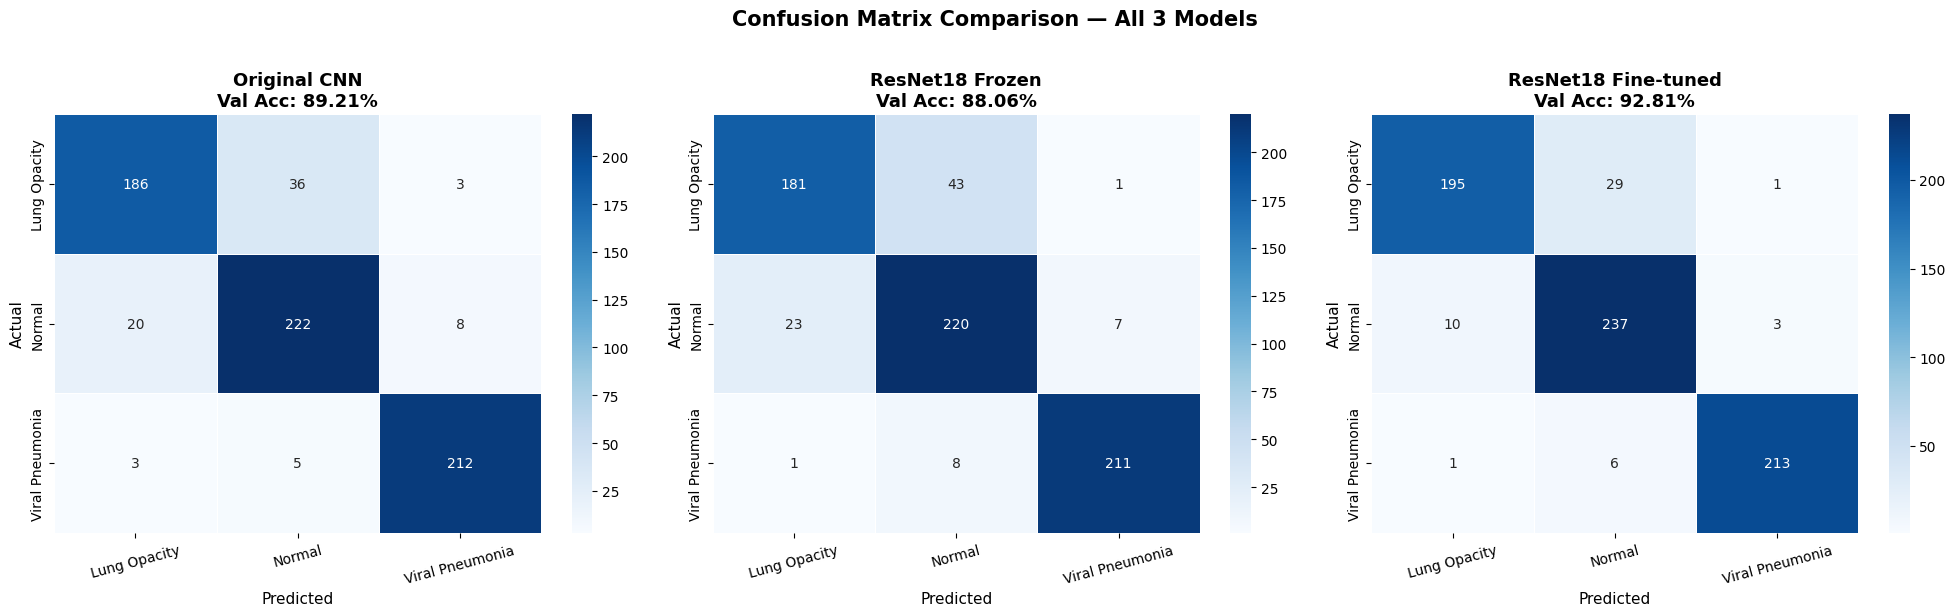


  Original CNN
                 precision    recall  f1-score   support

   Lung Opacity       0.89      0.83      0.86       225
         Normal       0.84      0.89      0.87       250
Viral Pneumonia       0.95      0.96      0.96       220

       accuracy                           0.89       695
      macro avg       0.89      0.89      0.89       695
   weighted avg       0.89      0.89      0.89       695


  ResNet18 Frozen
                 precision    recall  f1-score   support

   Lung Opacity       0.88      0.80      0.84       225
         Normal       0.81      0.88      0.84       250
Viral Pneumonia       0.96      0.96      0.96       220

       accuracy                           0.88       695
      macro avg       0.89      0.88      0.88       695
   weighted avg       0.88      0.88      0.88       695


  ResNet18 Fine-tuned
                 precision    recall  f1-score   support

   Lung Opacity       0.95      0.87      0.90       225
         Normal       0

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# ---------------- Config ----------------
img_size    = (224, 224)
batch_size  = 32
num_classes = 3
device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
valid_ext   = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')
class_names = ['Lung Opacity', 'Normal', 'Viral Pneumonia']

preprocessed_dirs = {
    "Lung_Opacity"   : "/kaggle/working/preprocessed_images/Lung_Opacity",
    "Normal"         : "/kaggle/working/preprocessed_images/Normal",
    "Viral_Pneumonia": "/kaggle/working/preprocessed_images/Viral_Pneumonia"
}

# ---------------- Load Paths ----------------
def get_image_paths_and_labels(dirs):
    image_paths, labels = [], []
    for i, (cls, path) in enumerate(dirs.items()):
        for f in os.listdir(path):
            if f.lower().endswith(valid_ext):
                image_paths.append(os.path.join(path, f))
                labels.append(i)
    return image_paths, labels

image_paths, labels = get_image_paths_and_labels(preprocessed_dirs)
_, test_paths, _, test_labels = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42
)

# ---------------- Datasets ----------------
class LungDatasetGray(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths; self.labels = labels; self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('L')
        return self.transform(img), self.labels[idx]

class LungDatasetRGB(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths; self.labels = labels; self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('L')
        return self.transform(img), self.labels[idx]

# Grayscale transform (for CNN)
cnn_transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# RGB transform (for ResNet)
resnet_transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

cnn_loader    = DataLoader(LungDatasetGray(test_paths, test_labels, cnn_transform),
                           batch_size=batch_size, shuffle=False)
resnet_loader = DataLoader(LungDatasetRGB(test_paths, test_labels, resnet_transform),
                           batch_size=batch_size, shuffle=False)

# ---------------- Model Definitions ----------------
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2,2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*28*28, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    def forward(self, x): return self.classifier(self.features(x))

def build_resnet(num_classes):
    m = models.resnet18(weights=None)
    m.fc = nn.Sequential(
        nn.Linear(m.fc.in_features, 256),
        nn.ReLU(), nn.Dropout(0.4),
        nn.Linear(256, num_classes)
    )
    return m

# ---------------- Predict Function ----------------
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, lbls in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.numpy())
    return np.array(all_labels), np.array(all_preds)

# ---------------- Load All 3 Models ----------------
# 1. Original CNN
cnn_model = SimpleCNN(num_classes).to(device)
cnn_model.load_state_dict(torch.load("/kaggle/working/best_cnn.pth",
                                      map_location=device))
print("✅ Original CNN loaded")

# 2. ResNet18 Frozen
resnet_frozen = build_resnet(num_classes).to(device)
resnet_frozen.load_state_dict(torch.load("/kaggle/working/resnet_phase1.pth",
                                          map_location=device))
print("✅ ResNet18 Frozen loaded")

# 3. ResNet18 Fine-tuned
resnet_ft = build_resnet(num_classes).to(device)
resnet_ft.load_state_dict(torch.load("/kaggle/working/resnet_phase2_best.pth",
                                      map_location=device))
print("✅ ResNet18 Fine-tuned loaded")

# ---------------- Get Predictions ----------------
y_true_cnn,    y_pred_cnn    = get_predictions(cnn_model,    cnn_loader)
y_true_frozen, y_pred_frozen = get_predictions(resnet_frozen, resnet_loader)
y_true_ft,     y_pred_ft     = get_predictions(resnet_ft,     resnet_loader)

# ---------------- Plot All 3 Confusion Matrices ----------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

models_data = [
    ("Original CNN",         y_true_cnn,    y_pred_cnn),
    ("ResNet18 Frozen",      y_true_frozen, y_pred_frozen),
    ("ResNet18 Fine-tuned",  y_true_ft,     y_pred_ft),
]

for ax, (title, y_true, y_pred) in zip(axes, models_data):
    cm  = confusion_matrix(y_true, y_pred)
    acc = 100 * np.sum(y_true == y_pred) / len(y_true)
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        xticklabels=class_names,
        yticklabels=class_names,
        cmap='Blues', linewidths=0.5
    )
    ax.set_title(f"{title}\nVal Acc: {acc:.2f}%", fontsize=13, fontweight='bold')
    ax.set_ylabel("Actual",    fontsize=11)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle("Confusion Matrix Comparison — All 3 Models",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ---------------- Classification Reports ----------------
for title, y_true, y_pred in models_data:
    print(f"\n{'='*55}")
    print(f"  {title}")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
from google.colab import drive
import shutil
import os

# ---------------- Mount Google Drive ----------------
drive.mount('/content/drive')

# ---------------- Create folder in Drive ----------------
save_dir = "/content/drive/MyDrive/lung_disease_models"
os.makedirs(save_dir, exist_ok=True)
print(f"Folder created: {save_dir}")

# ---------------- Copy models to Drive ----------------
models_to_save = {
    "original_cnn.pth"      : "/kaggle/working/best_cnn.pth",
    "resnet18_frozen.pth"   : "/kaggle/working/resnet_phase1.pth",
    "resnet18_finetuned.pth": "/kaggle/working/resnet_phase2_best.pth"
}

for save_name, source_path in models_to_save.items():
    dest_path = os.path.join(save_dir, save_name)
    if os.path.exists(source_path):
        shutil.copy2(source_path, dest_path)
        size_mb = os.path.getsize(dest_path) / (1024 * 1024)
        print(f"Saved: {save_name}  ({size_mb:.1f} MB)")
    else:
        print(f"Not found: {source_path}")

print(f"\nAll models saved to Google Drive at: {save_dir}")

Mounted at /content/drive
Folder created: /content/drive/MyDrive/lung_disease_models
Saved: original_cnn.pth  (98.4 MB)
Saved: resnet18_frozen.pth  (43.2 MB)
Saved: resnet18_finetuned.pth  (43.2 MB)

All models saved to Google Drive at: /content/drive/MyDrive/lung_disease_models
